# Technical Component

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from imblearn.pipeline import Pipeline, make_pipeline
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, average_precision_score

- **Credit Card Fraud Detection**
    - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download

In [7]:
df_credit = pd.read_csv("creditcard.csv")

In [8]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df_credit['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

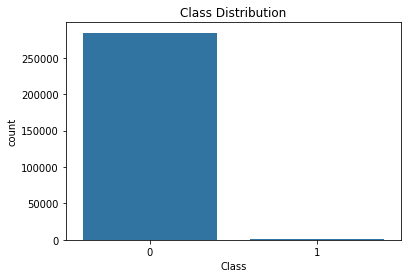

In [11]:
sns.countplot(x='Class', data=df_credit)
plt.title('Class Distribution')
plt.show()

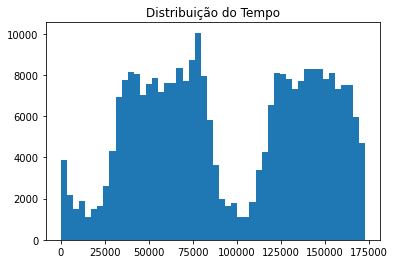

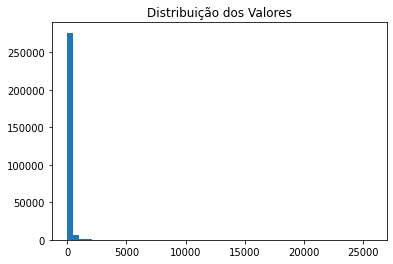

In [12]:
plt.hist(df_credit['Time'], bins=50)
plt.title('Distribuição do Tempo')
plt.show()

plt.hist(df_credit['Amount'], bins=50)
plt.title('Distribuição dos Valores')
plt.show()


In [13]:
df_credit['Amount_Scaled'] = StandardScaler().fit_transform(df_credit['Amount'].values.reshape(-1, 1))
df_credit['Time_Scaled'] = StandardScaler().fit_transform(df_credit['Time'].values.reshape(-1, 1))

# Remova as colunas originais se necessário
df_credit = df_credit.drop(['Time', 'Amount'], axis=1)


In [14]:
df_credit.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_Scaled,Time_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


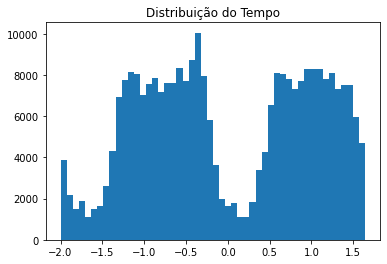

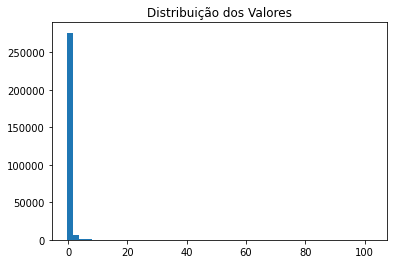

In [15]:
plt.hist(df_credit['Time_Scaled'], bins=50)
plt.title('Distribuição do Tempo')
plt.show()

plt.hist(df_credit['Amount_Scaled'], bins=50)
plt.title('Distribuição dos Valores')
plt.show()

In [16]:
X = df_credit.drop('Class', axis=1)
y = df_credit['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## Cross-Validation

Iremos usar cross validation 
Cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. The procedure has a single parameter called k that refers to the number of groups that a given data sample is to be split into. As such, the procedure is often called k-fold cross-validation.

The purpose of cross–validation is to test the ability of a machine learning model to predict new dat

Alterar texto e colocar uma imagema.

Stratified K-Fold CV (Cross-Validation)
Stratification is used when the datasets contain unbalanced classes. Therefore if we cross-validate with a normal technique it may produce subsamples that have a varying distribution of classes. Some unbalanced samples may produce exceptionally high scores leading to a high cross-validation score overall, which is undesirable. Therefore we create stratified subsamples that preserve the class frequencies in the individual folds to ensure that we are able to get a clear picture of the model performance.

In [19]:
kf = StratifiedKFold(n_splits=5, shuffle=False)


## Random Forest

In [17]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

score = cross_val_score(model_rf, X_train, y_train, scoring='recall', cv=kf)
print("Cross Validation Recall Scores are: {}".format(score))
print("Average Cross Validation Recall score: {}".format(score.mean()))

Cross Validation Recall Scores are: [0.84057971 0.73913043 0.7826087  0.79710145 0.79411765]
Average Cross Validation Recall score: 0.7907075873827791


In [21]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [30]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85291     4]
 [   36   112]]

          Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   0.965517  0.756757  0.848485  0.999532  0.731083


## Logistic Regression

In [31]:
model_lr = LogisticRegression(random_state=42)

score = cross_val_score(model_lr, X_train, y_train, scoring='recall', cv=kf)
print("Cross Validation Recall Scores are: {}".format(score))
print("Average Cross Validation Recall score: {}".format(score.mean()))

Cross Validation Recall Scores are: [0.72463768 0.5942029  0.66666667 0.66666667 0.54411765]
Average Cross Validation Recall score: 0.6392583120204602


In [32]:
model_lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [33]:
y_pred = model_lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

lr_Recall = recall_score(y_test, y_pred)
lr_Precision = precision_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_accuracy = accuracy_score(y_test, y_pred)
lr_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['Logistic Regression'], 
    'Precision': [lr_Precision],
    'Recall': [lr_Recall],
    'F1 Score': [lr_f1],
    'Accuracy': [lr_accuracy],
    'AUPRCC': [lr_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85280    15]
 [   57    91]]

                 Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  Logistic Regression   0.858491  0.614865  0.716535  0.999157  0.528523


## XGBoost

In [34]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

score = cross_val_score(model_xgb, X_train, y_train, scoring='recall', cv=kf)
print("Cross Validation Recall Scores are: {}".format(score))
print("Average Cross Validation Recall score: {}".format(score.mean()))

Cross Validation Recall Scores are: [0.82608696 0.8115942  0.8115942  0.82608696 0.79411765]
Average Cross Validation Recall score: 0.8138959931798807


In [35]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [36]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85279    16]
 [   31   117]]

     Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   0.879699  0.790541   0.83274   0.99945  0.695801


## Tecnicas de Balanceamento

### Random Oversampling

In [38]:
over = RandomOverSampler(random_state=42)

In [39]:
X_over, y_over = over.fit_resample(X_train, y_train)

In [42]:
print('0: ' + str(y_over.value_counts()[0]))
print('1: ' + str(y_over.value_counts()[1]))

0: 199020
1: 199020


In [54]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_over, y_over)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [55]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Oversampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85290     5]
 [   41   107]]

          Model            Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  Random Oversampling   0.955357  0.722973  0.823077  0.999462   

     AUPRCC  
0  0.691177  


### Random Undersampling

In [48]:
under = RandomUnderSampler(random_state=42)

In [50]:
X_under, y_under = under.fit_resample(X_train, y_train)

In [51]:
print('0: ' + str(y_under.value_counts()[0]))
print('1: ' + str(y_under.value_counts()[1]))

0: 344
1: 344


In [52]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_under, y_under)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [53]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Undersampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[83696  1599]
 [   21   127]]

          Model            Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  Random Oversampling   0.073581  0.858108  0.135539   0.98104   

     AUPRCC  
0  0.063386  


### SMOTE (Synthetic Minority Oversampling Technique)

In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribuição após SMOTE: {pd.Series(y_train_smote).value_counts()}")

Distribuição após SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [57]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [58]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85277    18]
 [   33   115]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest     SMOTE   0.864662  0.777027  0.818505  0.999403  0.672252


### B-SMOTE

In [20]:
bsmote = BorderlineSMOTE(random_state=42)
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train)

print(f"Distribuição após B-SMOTE: {pd.Series(y_train_smote).value_counts()}")

Distribuição após B-SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [21]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_bsmote, y_train_bsmote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [22]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['B-SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85290     5]
 [   37   111]]

          Model Technique  Precision  Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   B-SMOTE   0.956897    0.75  0.840909  0.999508  0.718105


### ADASYN 

In [12]:
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

In [13]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_adasyn, y_train_adasyn)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [15]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['ADASYN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85279    16]
 [   36   112]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest    ADASYN      0.875  0.756757  0.811594  0.999391  0.662583


### SMOTE-Tomek

In [18]:
SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')), 
                              RandomForestClassifier(n_estimators=50, random_state=42))

In [19]:
SMOTETomek_rf = SMOTETomek_pipeline
SMOTETomek_rf.fit(X_train, y_train)

AttributeError: 'Pipeline' object has no attribute '_check_fit_params'

In [ ]:
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train)

In [ ]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smote_tomek, y_train_smote_tomek)

In [ ]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_tmoest, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

### SMOTEENN

In [ ]:
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train, y_train)

In [ ]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smoteenn, y_train_smoteenn)

In [ ]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_tmoest, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTEENN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

### Hybrid Tomek Links BCBSMOTE (Proposed in Paper)

In [ ]:
# Passo 1: Clusterização e identificação de bordas
minority_class = X_train[y_train == 1]
kmeans = KMeans(n_clusters=5, random_state=42).fit(minority_class)

In [ ]:
# Passo 2: BCBSMOTE - Geração de amostras sintéticas
synthetic_samples = []
for cluster in range(5):
    cluster_data = minority_class[kmeans.labels_ == cluster]
    nbrs = NearestNeighbors(n_neighbors=5).fit(cluster_data)
    distances, indices = nbrs.kneighbors(cluster_data)
    for i, neighbors in enumerate(indices):
        for neighbor in neighbors:
            if neighbor != i:
                synthetic_sample = cluster_data[i] + np.random.rand() * (cluster_data[neighbor] - cluster_data[i])
                synthetic_samples.append(synthetic_sample)

synthetic_samples = np.array(synthetic_samples)
X_resampled = np.vstack([X_train, synthetic_samples])
y_resampled = np.hstack([y_train, np.ones(synthetic_samples.shape[0])])

In [ ]:
# Passo 3: Aplicar Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek2, y_train_smote_tomek2 = smote_tomek.fit_resample(X_resampled, y_resampled)

In [ ]:
# Passo 4: Treinar o modelo
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote_tomek2, y_train_smote_tomek2)

In [ ]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_tmoest, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

## Resultados

## Conclusão

**https://www.researchgate.net/publication/377619332_Hybrid_Undersampling_and_Oversampling_for_Handling_Imbalanced_Credit_Card_Data**